# Cluster the Clustering Monster — League of Legends edition (Task 1)

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

Every League of Legends champion carries 1–2 official **tags** (Fighter, Mage, Assassin, Tank, Marksman, Support). We treat these as multi-label ground truth and ask: **can unsupervised clustering on raw stats recover Riot's tags?**

**Pipeline**

1. Fetch champion stats + tags from Riot's Data Dragon CDN (cached after first run).
2. Light EDA, standardize, visualise with PCA.
3. Cluster three ways with tuning:
   - **K-Means** — elbow + silhouette for *k*
   - **DBSCAN** — k-distance plot for `eps`, small grid for `min_samples`
   - **Gaussian Mixture** — BIC for `n_components`
4. Compare internal (silhouette) and external (ARI / NMI vs primary tag) scores.
5. Use GMM's soft posteriors for **multi-label tag prediction**, evaluated with a stratified split and 5-fold CV.

In [42]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    jaccard_score,
    hamming_loss,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RNG = 42
np.random.seed(RNG)

# Pin to a specific patch so results stay reproducible across reruns.
PINNED_VERSION = "16.8.1"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_CSV = DATA_DIR / "lol_champions.csv"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Fetch the data (cached)

We hit three endpoints from Riot's free Data Dragon CDN: latest patch version, the champion overview (names + tags + rough info ratings), and one detail call per champion (full stats). After the first run we cache to a CSV so reruns are instant and reproducible.

In [43]:
DD_BASE = "https://ddragon.leagueoflegends.com"


def fetch_champions_dataframe(version: str) -> pd.DataFrame:
    """One row per champion: stats + info ratings + tags."""
    overview = requests.get(
        f"{DD_BASE}/cdn/{version}/data/en_US/champion.json", timeout=15
    ).json()["data"]

    rows = []
    for i, champ_id in enumerate(overview, 1):
        detail = requests.get(
            f"{DD_BASE}/cdn/{version}/data/en_US/champion/{champ_id}.json",
            timeout=15,
        ).json()["data"][champ_id]

        row = {
            "id": champ_id,
            "name": detail["name"],
            "title": detail["title"],
            "tags": ";".join(detail["tags"]),
            "primary_tag": detail["tags"][0],
            "n_tags": len(detail["tags"]),
            "partype": detail.get("partype", ""),
        }
        row.update({f"info_{k}": v for k, v in detail["info"].items()})
        row.update({f"stat_{k}": v for k, v in detail["stats"].items()})
        rows.append(row)
        time.sleep(0.02)
        if i % 30 == 0:
            print(f"  fetched {i}/{len(overview)}")
    return pd.DataFrame(rows)


if CACHE_CSV.exists():
    df = pd.read_csv(CACHE_CSV)
    print(f"Loaded {len(df)} champions from cache (patch {PINNED_VERSION}).")
else:
    print(f"Fetching live from Data Dragon, patch {PINNED_VERSION}...")
    df = fetch_champions_dataframe(PINNED_VERSION)
    df.to_csv(CACHE_CSV, index=False)
    print(f"Cached {len(df)} champions to {CACHE_CSV}.")

df.head()

Loaded 172 champions from cache (patch 16.8.1).


,id,name,title,tags,primary_tag,n_tags,partype,info_attack,info_defense,info_magic,...,stat_hpregen,stat_hpregenperlevel,stat_mpregen,stat_mpregenperlevel,stat_crit,stat_critperlevel,stat_attackdamage,stat_attackdamageperlevel,stat_attackspeedperlevel,stat_attackspeed
0,Aatrox,Aatrox,the Darkin Blade,Fighter,Fighter,1,Blood Well,8,4,3,...,3.00,0.50,0.0,0.0,0,0,60,0,2.500,0.651
1,Ahri,Ahri,the Nine-Tailed Fox,Mage;Assassin,Mage,2,Mana,3,4,8,...,2.50,0.60,8.0,0.8,0,0,53,0,2.200,0.668
2,Akali,Akali,the Rogue Assassin,Assassin,Assassin,1,Energy,5,3,8,...,9.00,0.90,50.0,0.0,0,0,62,0,3.200,0.625
3,Akshan,Akshan,the Rogue Sentinel,Marksman;Assassin,Marksman,2,Mana,0,0,0,...,3.75,0.65,8.2,0.7,0,0,52,0,4.000,0.638
4,Alistar,Alistar,the Minotaur,Tank;Support,Tank,2,Mana,6,9,5,...,8.50,0.85,8.5,0.8,0,0,62,0,2.125,0.625


## 2. Build the feature matrix

Two feature families:

- **`info_*`** — Riot's coarse 1–10 ratings: `attack`, `defense`, `magic`, `difficulty`.
- **`stat_*`** — base + per-level numerical stats: HP, mana, armour, attack damage, attack speed, range, regen, movespeed, etc.

That gives ~24 numerical features per champion.

In [44]:
INFO_COLS = [c for c in df.columns if c.startswith("info_")]
STAT_COLS = [c for c in df.columns if c.startswith("stat_")]
FEATURE_COLS = INFO_COLS + STAT_COLS

X_raw = df[FEATURE_COLS].astype(float).values
print(f"Feature matrix: {X_raw.shape[0]} champions x {X_raw.shape[1]} features")
print()
print("Info features:", INFO_COLS)
print("Stat features:", STAT_COLS)

Feature matrix: 172 champions x 24 features

Info features: ['info_attack', 'info_defense', 'info_magic', 'info_difficulty']
Stat features: ['stat_hp', 'stat_hpperlevel', 'stat_mp', 'stat_mpperlevel', 'stat_movespeed', 'stat_armor', 'stat_armorperlevel', 'stat_spellblock', 'stat_spellblockperlevel', 'stat_attackrange', 'stat_hpregen', 'stat_hpregenperlevel', 'stat_mpregen', 'stat_mpregenperlevel', 'stat_crit', 'stat_critperlevel', 'stat_attackdamage', 'stat_attackdamageperlevel', 'stat_attackspeedperlevel', 'stat_attackspeed']


## 3. Tag distribution (ground truth)

Some tags dominate (Fighter, Mage). Most champions have 1–2 tags, never more. Tag pairs like *Fighter+Tank* or *Mage+Support* are common — useful context for the multi-label step at the end.

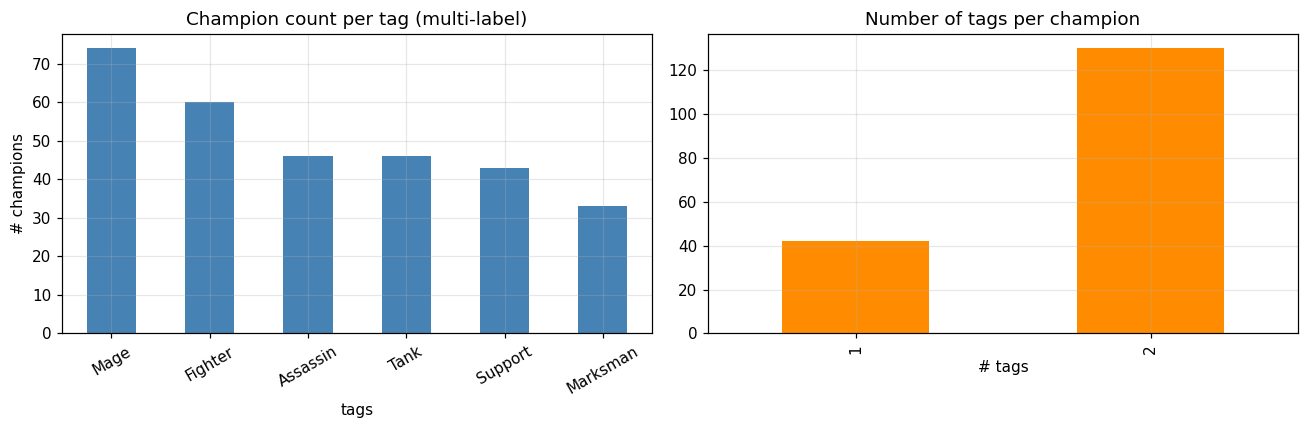

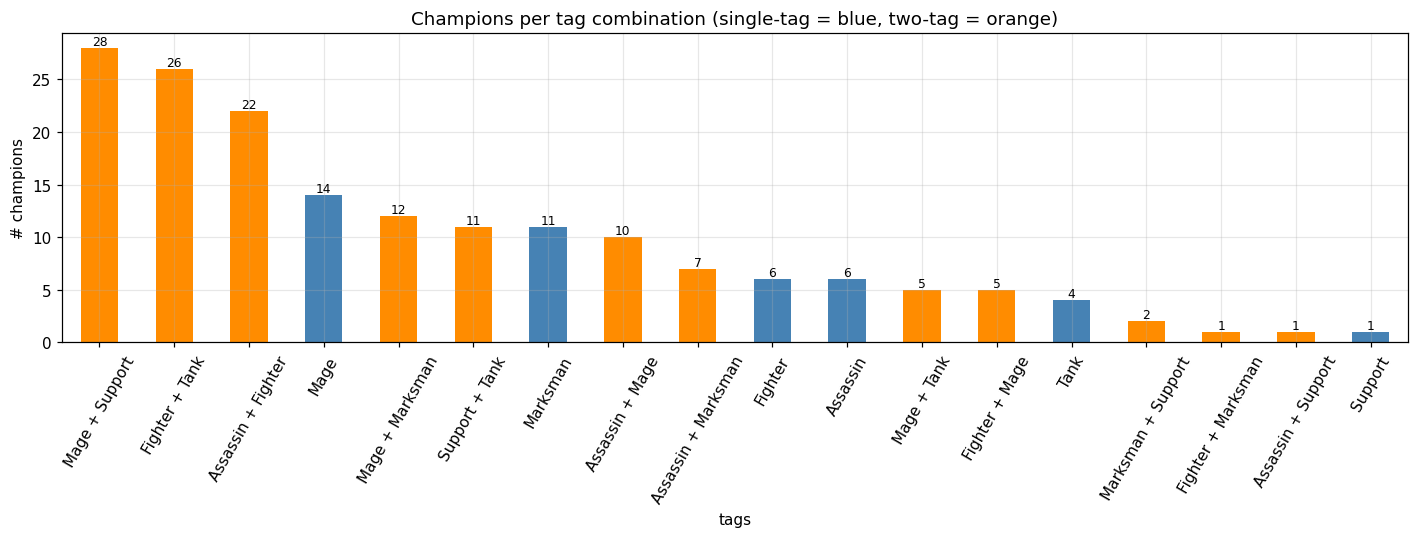

Total distinct tag combinations: 18
  single-tag combinations: 6
  two-tag combinations   : 12


In [45]:
all_tags = df["tags"].str.split(";").explode()
tag_counts = all_tags.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tag_counts.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Champion count per tag (multi-label)")
axes[0].set_ylabel("# champions")
axes[0].tick_params(axis="x", rotation=30)

df["n_tags"].value_counts().sort_index().plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Number of tags per champion")
axes[1].set_xlabel("# tags")
plt.tight_layout()
plt.show()

# Every distinct tag combination (1-tag and 2-tag champions together),
# canonicalised by sorting tags alphabetically and joining with " + ".
combo_counts = (
    df["tags"]
    .apply(lambda s: " + ".join(sorted(s.split(";"))))
    .value_counts()
)
combo_colors = ["steelblue" if " + " not in c else "darkorange" for c in combo_counts.index]

fig, ax = plt.subplots(figsize=(13, 5))
combo_counts.plot.bar(ax=ax, color=combo_colors)
ax.set_title("Champions per tag combination (single-tag = blue, two-tag = orange)")
ax.set_ylabel("# champions")
ax.tick_params(axis="x", rotation=60)
for i, v in enumerate(combo_counts.values):
    ax.text(i, v + 0.3, str(int(v)), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

n_single = sum(1 for c in combo_counts.index if " + " not in c)
n_double = sum(1 for c in combo_counts.index if " + "     in c)
print(f"Total distinct tag combinations: {len(combo_counts)}")
print(f"  single-tag combinations: {n_single}")
print(f"  two-tag combinations   : {n_double}")

## 4. Standardize + PCA visualisation

Features have wildly different scales (HP ~600, attackspeed ~0.7) — we z-score them so HP doesn't dominate distance computations. PCA to 2-D is for **visualisation only**; clustering runs in the full 24-dim standardized space.

PCA cumulative explained variance (2 comps): 37.3%


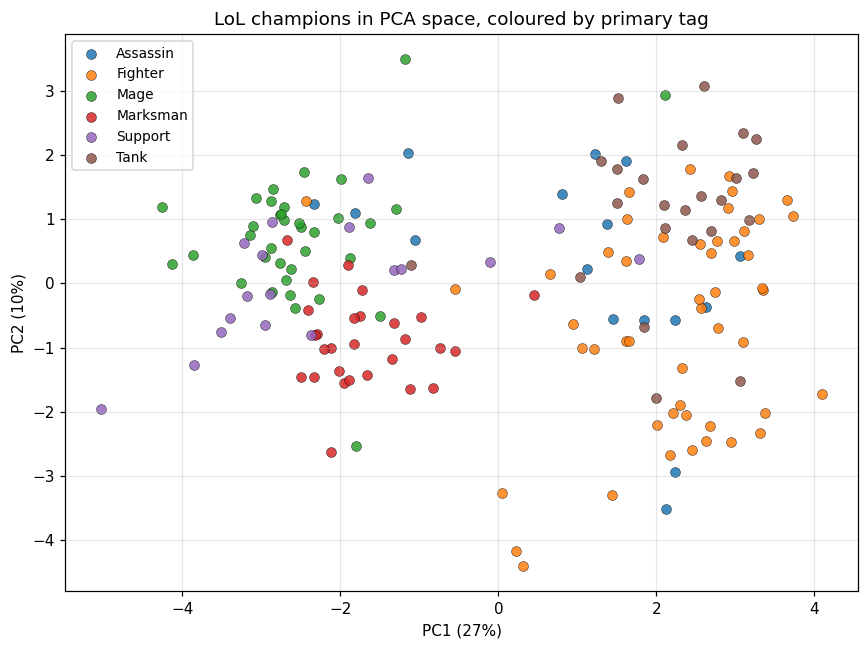

In [46]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=RNG)
X2 = pca.fit_transform(X)
print(f"PCA cumulative explained variance (2 comps): {pca.explained_variance_ratio_.sum():.1%}")

primary_tags = sorted(df["primary_tag"].unique())
cmap = plt.get_cmap("tab10")
tag_to_color = {t: cmap(i % 10) for i, t in enumerate(primary_tags)}

plt.figure(figsize=(8, 6))
for tag in primary_tags:
    mask = df["primary_tag"].values == tag
    plt.scatter(X2[mask, 0], X2[mask, 1], s=42, alpha=0.85,
                color=tag_to_color[tag], label=tag,
                edgecolor="black", linewidth=0.3)
plt.legend(loc="best", fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.title("LoL champions in PCA space, coloured by primary tag")
plt.tight_layout()
plt.show()


In [47]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=["PC1", "PC2"],
)

for pc in ["PC1", "PC2"]:
    print(f"\n=== {pc} loadings (sorted by |value|) ===")
    ordered = loadings.reindex(loadings[pc].abs().sort_values(ascending=False).index)
    print(ordered[pc].round(3))


=== PC1 loadings (sorted by |value|) ===
stat_spellblockperlevel      0.378
stat_attackrange            -0.376
stat_attackdamage            0.340
stat_armor                   0.338
stat_movespeed               0.275
stat_hp                      0.251
stat_hpregen                 0.245
stat_spellblock              0.242
info_defense                 0.227
stat_hpregenperlevel         0.209
info_magic                  -0.200
info_attack                  0.180
stat_mpregenperlevel        -0.146
stat_hpperlevel              0.138
stat_attackspeed             0.089
stat_armorperlevel           0.077
info_difficulty             -0.062
stat_attackspeedperlevel     0.056
stat_mpperlevel             -0.023
stat_mpregen                 0.004
stat_mp                     -0.000
stat_crit                   -0.000
stat_critperlevel           -0.000
stat_attackdamageperlevel   -0.000
Name: PC1, dtype: float64

=== PC2 loadings (sorted by |value|) ===
stat_mpregenperlevel         0.483
stat_mpperlevel

## (NERDY) Interpretation

The PCA axes tell one clear story: **melee vs ranged**.

**PC1 (27%) — melee identity bundle.** `attackrange` loads strongly negative (-0.38), while every melee survivability stat loads positive: spell block/level (+0.38), AD (+0.34), armor (+0.34), MS (+0.28), HP (+0.25), HP regen (+0.25). This is Riot's fundamental design tradeoff: champions either get to stand far away, or they get the stats to survive being close. PC1 captures that whole package in one axis, which is why it explains so much variance.

**PC2 (10%) — spell-caster scaling vs auto-attack scaling.** Dominated by `mpperlevel` (+0.46) and `mpregenperlevel` (+0.48) on the positive side and `info_attack` (-0.34) / `attackspeedperlevel` (-0.19) on the negative. Manaless champions anchor the bottom since their mana scaling is literally 0.

**The four quadrants, read naturally:**
- Top-left: ranged casters (mages)
- Bottom-left: ranged auto-attackers (marksmen)
- Top-right: melee with ability/tank scaling (tanks)
- Bottom-right: melee auto-attackers (fighters, melee assassins)

## 5. Method 1 — K-Means

K-Means partitions the standardized space into *k* clusters by minimising within-cluster SSE (the **inertia**). The underlying assumption is that the data decomposes into *k* roughly spherical, equal-variance blobs — a strong prior that breaks if the true cluster shapes differ.

Two complementary criteria for picking *k*:

- **Elbow** on inertia — look for the bend where adding a cluster stops paying off.
- **Silhouette** — mean $(b - a)/\max(a, b)$ per point; higher means tighter clusters with more separation.

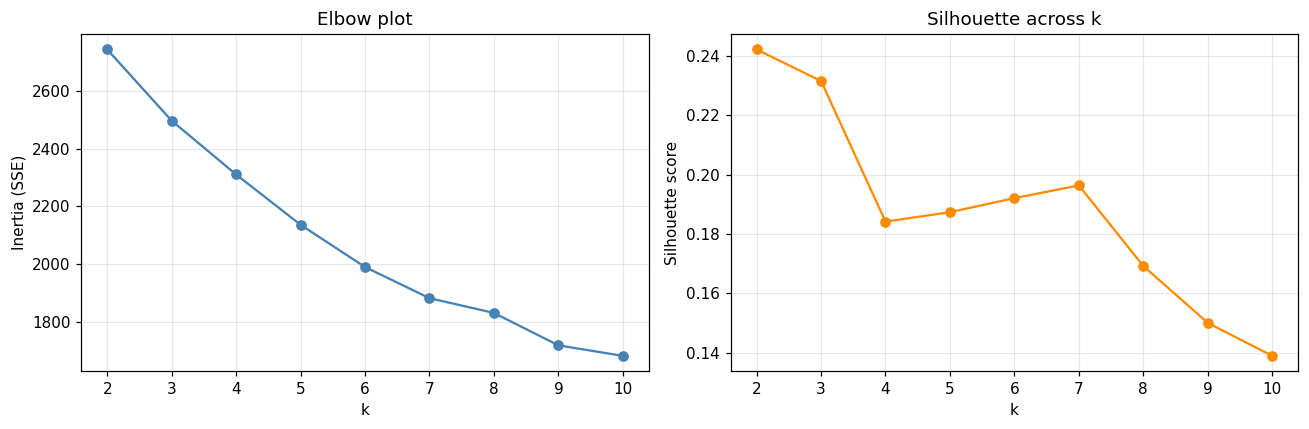

Best k by silhouette: 2 (score=0.242)


In [48]:
ks = list(range(2, 11))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, "o-", color="steelblue")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow plot")
axes[1].plot(ks, silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette across k")
plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k} (score={max(silhouettes):.3f})")

### Why does k=2 win?

A silhouette of 0.24 is modest (1.0 is perfect, 0 means clusters touch). The fact that it peaks at the smallest *k* we tried is itself a finding: in standardised stat-space there is **one dominant split** — the same melee-vs-ranged axis we saw along PC1 — with no equally clean sub-divisions on top of it.

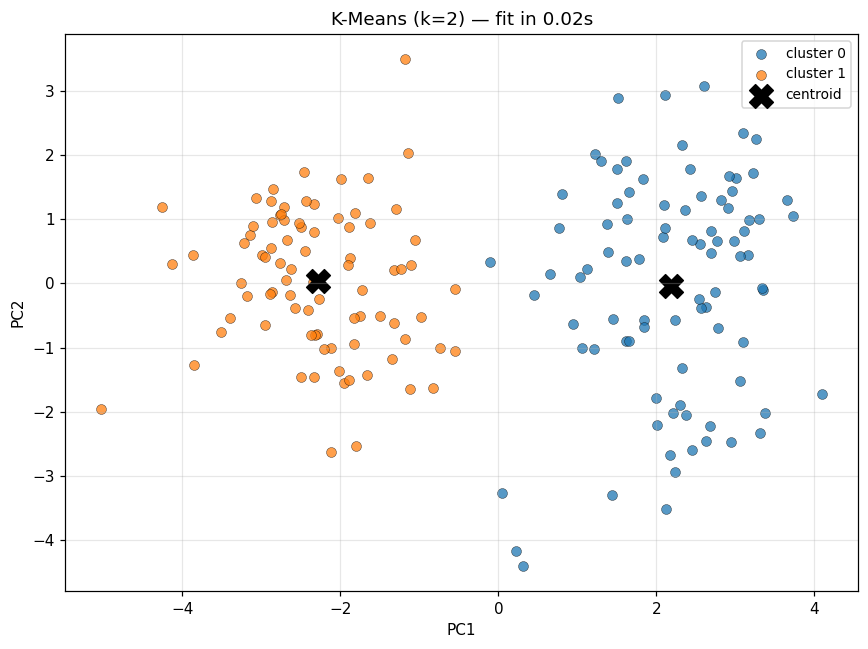

In [49]:
KMEANS_K = best_k  # change here to override

t0 = time.time()
kmeans = KMeans(n_clusters=KMEANS_K, n_init=50, max_iter=500, random_state=RNG)
y_kmeans = kmeans.fit_predict(X)
t_kmeans = time.time() - t0

centroids2 = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
for c in range(KMEANS_K):
    mask = y_kmeans == c
    plt.scatter(X2[mask, 0], X2[mask, 1], s=42, alpha=0.75,
                color=cmap(c % 10), label=f"cluster {c}",
                edgecolor="black", linewidth=0.3)
plt.scatter(centroids2[:, 0], centroids2[:, 1], marker="X", s=240,
            color="black", label="centroid")
plt.legend(loc="best", fontsize=9)
plt.title(f"K-Means (k={KMEANS_K}) — fit in {t_kmeans:.2f}s")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

## 6. Method 2 — DBSCAN

DBSCAN finds **dense** regions, grows them into clusters of arbitrary shape, and labels low-density points as noise (`-1`). Two hyperparameters:

- `eps` — neighbourhood radius. Chosen from the **k-distance plot**: sort each point's distance to its *k*-th nearest neighbour, look for the knee.
- `min_samples` — minimum neighbours required to be a *core* point.

We sweep a grid around the heuristic `eps` and keep the highest silhouette, filtering configs with <2 or >8 clusters or more than **30% noise** — beyond that the silhouette is computed on a sliver of the data and the comparison loses meaning.

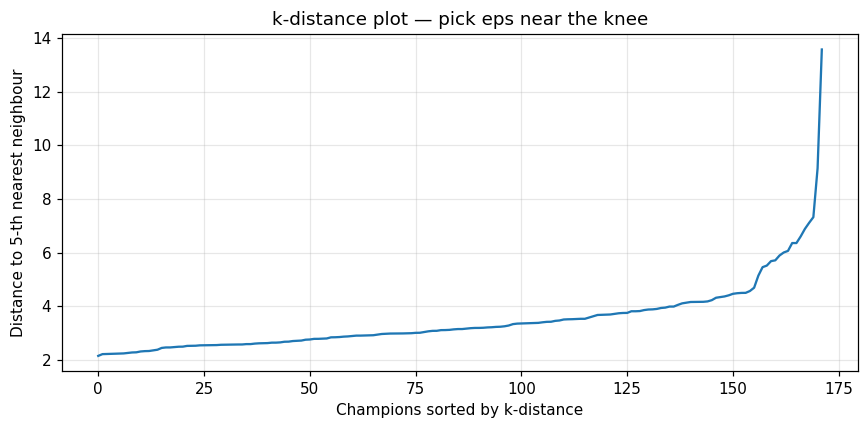

Heuristic eps (90th percentile of k-dist) = 4.557


In [50]:
k_for_kdist = 5
nn = NearestNeighbors(n_neighbors=k_for_kdist).fit(X)
dists, _ = nn.kneighbors(X)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kdist)
plt.xlabel("Champions sorted by k-distance")
plt.ylabel(f"Distance to {k_for_kdist}-th nearest neighbour")
plt.title("k-distance plot — pick eps near the knee")
plt.tight_layout(); plt.show()

eps_guess = float(np.quantile(kdist, 0.9))
print(f"Heuristic eps (90th percentile of k-dist) = {eps_guess:.3f}")

In [51]:
eps_grid = np.linspace(eps_guess * 0.6, eps_guess * 1.4, 9)
ms_grid = [3, 5, 8]

results = []
for eps in eps_grid:
    for ms in ms_grid:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        n_clusters = len({l for l in labels if l != -1})
        n_noise = int(np.sum(labels == -1))
        non_noise_mask = labels != -1
        if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
            sil = silhouette_score(X[non_noise_mask], labels[non_noise_mask])
        else:
            sil = np.nan
        results.append({
            "eps": round(float(eps), 3),
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil,
        })

dbscan_grid = pd.DataFrame(results)
dbscan_grid

,eps,min_samples,n_clusters,n_noise,silhouette
0,2.734,3,3,84,0.335158
1,2.734,5,4,89,0.215125
2,2.734,8,3,116,0.402981
3,3.190,3,3,51,0.302140
4,3.190,5,2,58,0.349237
5,3.190,8,2,60,0.352992
6,3.646,3,2,29,0.308532
7,3.646,5,1,34,NaN
8,3.646,8,1,38,NaN
9,4.102,3,2,14,0.291838


Picked DBSCAN config:
eps             3.646000
min_samples     3.000000
n_clusters      2.000000
n_noise        29.000000
silhouette      0.308532


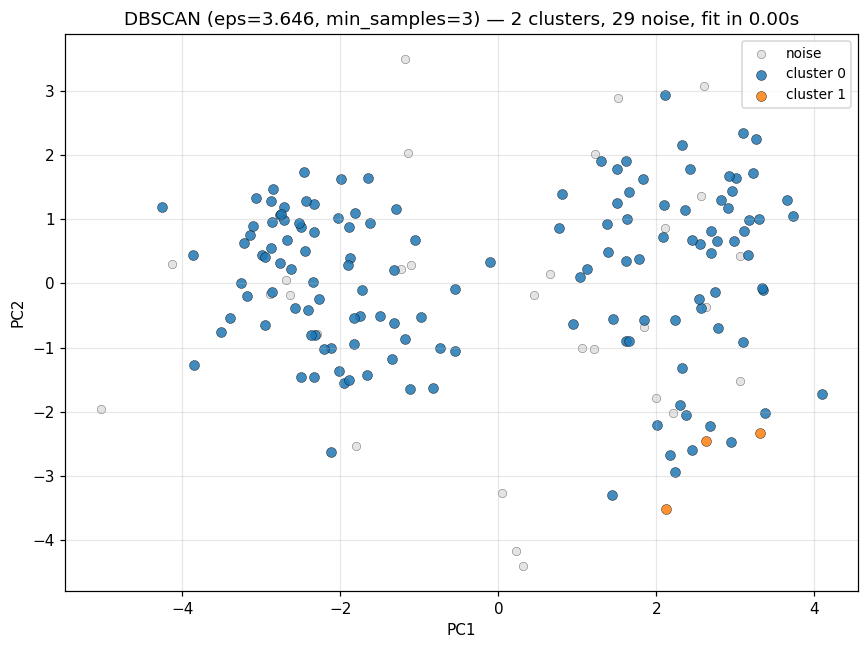

In [52]:
MAX_NOISE_FRAC = 0.30
noise_cap = int(MAX_NOISE_FRAC * len(X))

viable = dbscan_grid.dropna(subset=["silhouette"])
viable = viable[viable["n_clusters"].between(2, 8) & (viable["n_noise"] <= noise_cap)]
if viable.empty:
    raise RuntimeError(
        f"No DBSCAN config kept noise <= {noise_cap} with 2-8 clusters; widen the grid."
    )
best = viable.sort_values("silhouette", ascending=False).iloc[0]
print("Picked DBSCAN config:")
print(best.to_string())

t0 = time.time()
dbscan = DBSCAN(eps=float(best["eps"]), min_samples=int(best["min_samples"]))
y_dbscan = dbscan.fit_predict(X)
t_dbscan = time.time() - t0

unique_labels = sorted(set(y_dbscan))
plt.figure(figsize=(8, 6))
for c in unique_labels:
    mask = y_dbscan == c
    if c == -1:
        plt.scatter(X2[mask, 0], X2[mask, 1], s=30, color="lightgray",
                    label="noise", edgecolor="black", linewidth=0.3, alpha=0.6)
    else:
        plt.scatter(X2[mask, 0], X2[mask, 1], s=42, color=cmap(c % 10),
                    label=f"cluster {c}", edgecolor="black", linewidth=0.3, alpha=0.85)
plt.legend(loc="best", fontsize=9)
plt.title(
    f"DBSCAN (eps={best['eps']}, min_samples={int(best['min_samples'])}) — "
    f"{int(best['n_clusters'])} clusters, {int(best['n_noise'])} noise, "
    f"fit in {t_dbscan:.2f}s"
)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

## 7. Method 3 — Gaussian Mixture (EM)

GMM is the soft-assignment cousin of K-Means: it fits a weighted mixture of full-covariance Gaussians via EM and returns posteriors `P(cluster | champion)`. Unlike K-Means it can model elongated, correlated clusters. Model order is chosen by **BIC** (lower is better; it penalises extra components more aggressively than AIC). Those soft probabilities also drive the multi-label prediction in §9.

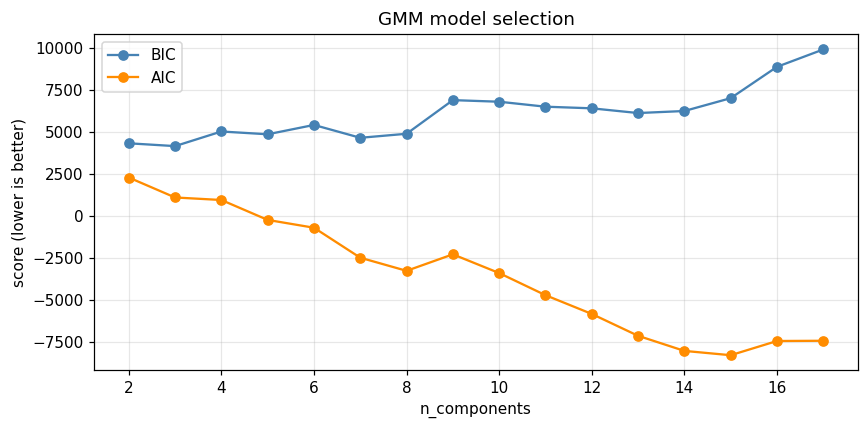

Best n_components by BIC: 3


In [53]:
ks = list(range(2, 18))
bics, aics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type="full",
                        n_init=5, random_state=RNG)
    g.fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, bics, "o-", label="BIC", color="steelblue")
ax.plot(ks, aics, "o-", label="AIC", color="darkorange")
ax.set_xlabel("n_components"); ax.set_ylabel("score (lower is better)")
ax.set_title("GMM model selection")
ax.legend()
plt.tight_layout(); plt.show()

best_k_gmm = ks[int(np.argmin(bics))]
print(f"Best n_components by BIC: {best_k_gmm}")

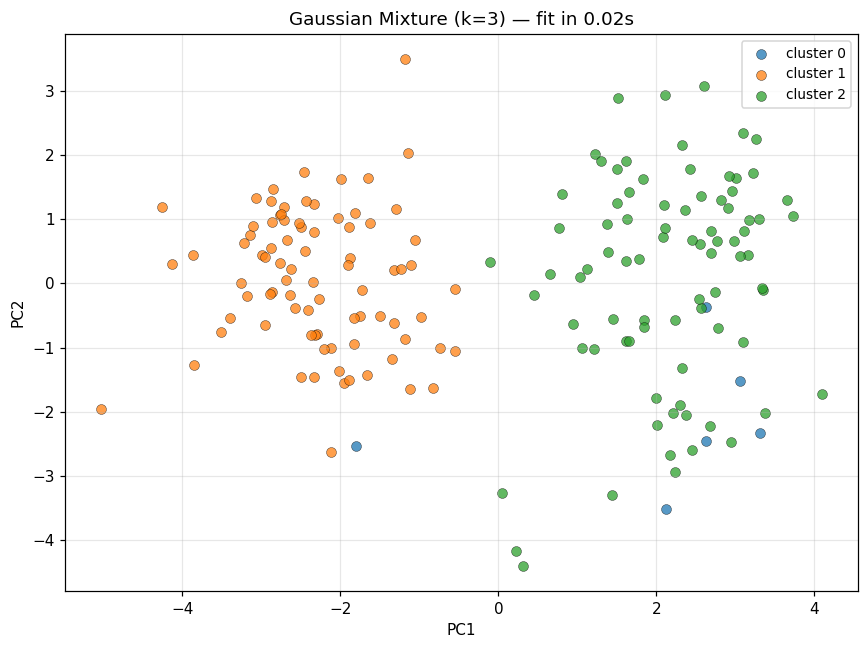

In [54]:
GMM_K = best_k_gmm  # change here to override

t0 = time.time()
gmm = GaussianMixture(n_components=GMM_K, covariance_type="full",
                      n_init=10, random_state=RNG)
gmm.fit(X)
y_gmm = gmm.predict(X)
proba_gmm = gmm.predict_proba(X)
t_gmm = time.time() - t0

plt.figure(figsize=(8, 6))
for c in range(GMM_K):
    mask = y_gmm == c
    plt.scatter(X2[mask, 0], X2[mask, 1], s=42, alpha=0.75,
                color=cmap(c % 10), label=f"cluster {c}",
                edgecolor="black", linewidth=0.3)
plt.legend(loc="best", fontsize=9)
plt.title(f"Gaussian Mixture (k={GMM_K}) — fit in {t_gmm:.2f}s")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

## 8. Method comparison

We score every method on:

- **Silhouette** — internal cluster quality, no labels needed. **Note:** DBSCAN's silhouette is computed only on its non-noise points (143 of 172), so it isn't directly comparable to K-Means/GMM silhouettes computed on all 172.
- **ARI / NMI vs primary tag** — agreement with Riot's single-label classification.
- **Runtime**.

Caveat: Riot's tags are not a pure stat-based clustering — a Mage and an Assassin can have very similar HP/AD profiles yet belong to different tags by playstyle. So we don't expect ARI ≈ 1; we want the *relative* ordering between methods.

In [55]:
def cluster_quality(name, labels, runtime):
    """Silhouette + ARI/NMI vs primary tag, with DBSCAN noise excluded."""
    mask = labels != -1
    L = labels[mask]
    n_unique = len(set(L))
    if n_unique < 2 or len(L) <= n_unique:
        sil = np.nan
    else:
        sil = silhouette_score(X[mask], L)
    truth = df["primary_tag"].values[mask]
    return {
        "method": name,
        "n_clusters": n_unique,
        "n_noise": int((~mask).sum()),
        "silhouette": round(float(sil), 3) if not np.isnan(sil) else np.nan,
        "ARI vs primary tag": round(adjusted_rand_score(truth, L), 3),
        "NMI vs primary tag": round(normalized_mutual_info_score(truth, L), 3),
        "runtime (s)": round(runtime, 3),
    }

summary = pd.DataFrame([
    cluster_quality("KMeans", y_kmeans, t_kmeans),
    cluster_quality("DBSCAN", y_dbscan, t_dbscan),
    cluster_quality("GMM",    y_gmm,    t_gmm),
])
summary

,method,n_clusters,n_noise,silhouette,ARI vs primary tag,NMI vs primary tag,runtime (s)
0,KMeans,2,0,0.242,0.307,0.390,0.020
1,DBSCAN,2,29,0.309,-0.003,0.024,0.001
2,GMM,3,0,0.253,0.299,0.368,0.017


## 9. Multi-label tag prediction via GMM soft assignment

Champions carry up to two tags, but hard clustering emits only one label per point. We exploit two facts: (1) GMM gives posteriors `P(cluster | champion)`, and (2) each cluster has its own **mixture of tags** (a Fighter-dominant cluster also contains many Fighter+Tank champions). Together they give a probabilistic multi-label predictor.

**Two design choices worth flagging:**

- *K=6 here, not the BIC-chosen K=3 from §7.* BIC penalises extra components and picks small K on small samples. For multi-label we need enough granularity to resolve all six tag families, so we re-fit with `K = |tags| = 6` ("GMM-multi").
- *A train/test split is required.* The clustering itself is unsupervised, but the **cluster→tag profile mapping is supervised** (we average true tags inside each cluster). Evaluating it on the same champions used to learn it would be optimistic. So: stratified 80/20 split, fit GMM-multi on train only, build profiles from train tags only, report both splits.

**Pipeline**

1. Stratified 80/20 split on `primary_tag`.
2. Fit GMM-multi (K=6) on train.
3. For each cluster *c*, compute the **mean multi-hot tag profile** of its train members: $p_c \in [0,1]^{|\text{tags}|}$.
4. Expected tag profile per champion: $\hat p_i = \sum_c P(c \mid x_i) \cdot p_c$.
5. Predict the **top-2 tags** of $\hat p_i$.
6. Score both splits with exact-match, sample-Jaccard, Hamming loss.

*Caveat:* most champions carry only 1 tag (see §3), so always predicting 2 structurally caps exact-match well below 100% — read the Jaccard scores alongside it, not just exact-match.

In [56]:
tag_universe = sorted(all_tags.unique())
tag_idx = {t: i for i, t in enumerate(tag_universe)}


def tags_to_vec(tag_list):
    """Multi-hot vector over tag_universe."""
    v = np.zeros(len(tag_universe))
    for t in tag_list:
        v[tag_idx[t]] = 1.0
    return v


def build_cluster_profiles(Y_slice, cluster_labels, n_clusters):
    """Mean multi-hot tag profile per cluster (used with TRAIN slices only)."""
    profiles = np.zeros((n_clusters, Y_slice.shape[1]))
    for c in range(n_clusters):
        members = cluster_labels == c
        if members.any():
            profiles[c] = Y_slice[members].mean(axis=0)
    return profiles


def top_k_multi_hot(expected, k):
    """Binarise a profile matrix by keeping the top-k entries per row."""
    top = np.argsort(-expected, axis=1)[:, :k]
    Y = np.zeros_like(expected)
    for i, row in enumerate(top):
        Y[i, row] = 1.0
    return Y


true_tag_lists = df["tags"].str.split(";").apply(sorted).tolist()
Y_true = np.vstack([tags_to_vec(t) for t in true_tag_lists])

# Stratified 80/20 split on the primary tag
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    random_state=RNG,
    stratify=df["primary_tag"].values,
)
print(f"Split: {len(train_idx)} train / {len(test_idx)} test")
print("Primary tag distribution:")
print(pd.DataFrame({
    "train": df.iloc[train_idx]["primary_tag"].value_counts(),
    "test":  df.iloc[test_idx]["primary_tag"].value_counts(),
}).fillna(0).astype(int))

Split: 137 train / 35 test
Primary tag distribution:
             train  test
primary_tag             
Fighter         40    10
Mage            29     7
Marksman        22     6
Tank            19     5
Support         14     4
Assassin        13     3


In [57]:
# Fit GMM specifically for the multi-label task — TRAIN ONLY
GMM_K_MULTI = 6  # = number of Riot tags

gmm_multi = GaussianMixture(
    n_components=GMM_K_MULTI, covariance_type="full",
    n_init=10, random_state=RNG,
)
gmm_multi.fit(X[train_idx])

proba_train = gmm_multi.predict_proba(X[train_idx])
proba_test  = gmm_multi.predict_proba(X[test_idx])
y_train_clusters = gmm_multi.predict(X[train_idx])

cluster_tag_profiles = build_cluster_profiles(
    Y_true[train_idx], y_train_clusters, GMM_K_MULTI
)
cluster_sizes = np.bincount(y_train_clusters, minlength=GMM_K_MULTI)

profiles_df = pd.DataFrame(
    cluster_tag_profiles.round(2),
    columns=tag_universe,
    index=[f"cluster {c} (n_train={cluster_sizes[c]})" for c in range(GMM_K_MULTI)],
)
print("Per-cluster tag profile (TRAIN-derived):")
profiles_df

Per-cluster tag profile (TRAIN-derived):


,Assassin,Fighter,Mage,Marksman,Support,Tank
cluster 0 (n_train=13),0.15,0.31,0.08,0.00,0.54,0.85
cluster 1 (n_train=44),0.11,0.05,0.95,0.09,0.55,0.00
cluster 2 (n_train=10),0.30,0.50,0.10,0.00,0.10,0.60
cluster 3 (n_train=24),0.29,0.04,0.25,0.88,0.12,0.08
cluster 4 (n_train=18),0.50,0.89,0.11,0.00,0.00,0.33
cluster 5 (n_train=28),0.43,0.71,0.11,0.04,0.00,0.43


In [58]:
TOP_K = 2

Y_train_pred = top_k_multi_hot(proba_train @ cluster_tag_profiles, TOP_K)
Y_test_pred  = top_k_multi_hot(proba_test  @ cluster_tag_profiles, TOP_K)


def multilabel_score(name, Y_t, Y_p):
    return {
        "split": name,
        "exact_match": float((Y_t == Y_p).all(axis=1).mean()),
        "jaccard_samples": jaccard_score(Y_t, Y_p, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(Y_t, Y_p),
    }

multilabel_scores = pd.DataFrame([
    multilabel_score("train (in-sample)", Y_true[train_idx], Y_train_pred),
    multilabel_score("test  (held-out)",  Y_true[test_idx],  Y_test_pred),
])
multilabel_scores

,split,exact_match,jaccard_samples,hamming_loss
0,train (in-sample),0.364964,0.59854,0.186131
1,test (held-out),0.228571,0.40000,0.328571


In [59]:
# Per-tag Jaccard on the held-out test set
per_tag_test = {
    t: jaccard_score(Y_true[test_idx][:, i], Y_test_pred[:, i], zero_division=0)
    for i, t in enumerate(tag_universe)
}
print("Per-tag Jaccard on TEST set:")
for t, v in sorted(per_tag_test.items(), key=lambda kv: -kv[1]):
    print(f"  {t:<10} : {v:.3f}")

Per-tag Jaccard on TEST set:
  Mage       : 0.567
  Fighter    : 0.357
  Support    : 0.286
  Assassin   : 0.154
  Marksman   : 0.000
  Tank       : 0.000


In [60]:
# Robustness: 5-fold stratified CV so per-tag scores aren't one-split flukes
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
fold_rows = []
per_tag_oof = np.zeros((len(df), len(tag_universe)))

for fold, (tr, te) in enumerate(
    skf.split(np.arange(len(df)), df["primary_tag"].values), 1
):
    g = GaussianMixture(n_components=GMM_K_MULTI, covariance_type="full",
                        n_init=5, random_state=RNG)
    g.fit(X[tr])
    profiles = build_cluster_profiles(Y_true[tr], g.predict(X[tr]), GMM_K_MULTI)
    Yp_te = top_k_multi_hot(g.predict_proba(X[te]) @ profiles, TOP_K)
    per_tag_oof[te] = Yp_te

    fold_rows.append({
        "fold": fold,
        "n_test": len(te),
        "exact_match": float((Y_true[te] == Yp_te).all(axis=1).mean()),
        "jaccard": jaccard_score(Y_true[te], Yp_te, average="samples", zero_division=0),
        "hamming": hamming_loss(Y_true[te], Yp_te),
    })

cv = pd.DataFrame(fold_rows)
print("5-fold CV per fold:")
print(cv.to_string(index=False))
print()
print("Aggregate out-of-fold (every champion held out exactly once):")
print(f"  Exact-match : {(Y_true == per_tag_oof).all(axis=1).mean():.3f}")
print(f"  Jaccard     : {jaccard_score(Y_true, per_tag_oof, average='samples', zero_division=0):.3f}")
print(f"  Hamming     : {hamming_loss(Y_true, per_tag_oof):.3f}")
print()
print("Per-tag out-of-fold Jaccard:")
for i, t in enumerate(tag_universe):
    j = jaccard_score(Y_true[:, i], per_tag_oof[:, i], zero_division=0)
    print(f"  {t:<10} : {j:.3f}")

5-fold CV per fold:
 fold  n_test  exact_match  jaccard  hamming
    1      35     0.257143 0.423810 0.304762
    2      35     0.257143 0.400000 0.338095
    3      34     0.323529 0.485294 0.269608
    4      34     0.117647 0.397059 0.299020
    5      34     0.470588 0.647059 0.161765

Aggregate out-of-fold (every champion held out exactly once):
  Exact-match : 0.285
  Jaccard     : 0.470
  Hamming     : 0.275

Per-tag out-of-fold Jaccard:
  Assassin   : 0.000
  Fighter    : 0.505
  Mage       : 0.525
  Marksman   : 0.306
  Support    : 0.314
  Tank       : 0.412


In [61]:
# Qualitative examples drawn from the held-out TEST set
predicted_tag_lists_test = [
    sorted([tag_universe[j] for j in np.where(Y_test_pred[i])[0]])
    for i in range(len(test_idx))
]

preview = df.iloc[test_idx][["name", "tags"]].copy().reset_index(drop=True)
preview["predicted_tags"] = [";".join(p) for p in predicted_tag_lists_test]
preview["match"] = [
    sorted(predicted_tag_lists_test[i]) == sorted(preview.loc[i, "tags"].split(";"))
    for i in range(len(preview))
]
preview.head(15)

,name,tags,predicted_tags,match
0,Ziggs,Mage,Mage;Support,False
1,Galio,Tank;Mage,Assassin;Fighter,False
2,Janna,Support;Mage,Mage;Support,True
3,Volibear,Fighter;Tank,Assassin;Fighter,False
4,Trundle,Fighter;Tank,Assassin;Fighter,False
5,Poppy,Tank;Fighter,Assassin;Fighter,False
6,Akshan,Marksman;Assassin,Mage;Support,False
7,Olaf,Fighter;Tank,Mage;Support,False
8,Lee Sin,Fighter;Assassin,Mage;Support,False
9,Maokai,Tank;Support,Mage;Support,False


## 10. Take-aways

**Unsupervised method comparison**

| Method | Strength | Weakness here |
|---|---|---|
| K-Means | Fast, clean partitions | Silhouette pins *k*=2 — only finds the global melee/ranged axis |
| DBSCAN | Handles non-convex shapes | Stats form a continuous manifold with no density gaps → brittle; ARI ≈ 0 even with the noise filter |
| GMM (BIC K=3) | Soft posteriors enable multi-label | Hard-assignment ARI/NMI similar to K-Means |

**Multi-label prediction.** 5-fold stratified CV gives out-of-fold Jaccard ≈ **0.47** and exact-match ≈ **29%** (the single 80/20 split showed a ~20pt train/test gap with high variance, hence the CV). Per-tag Jaccard: Mage 0.53, Fighter 0.51, Tank 0.41, Support 0.31, Marksman 0.31, **Assassin 0.00**. The Assassin zero is structural: no cluster's average profile is ever Assassin-dominant (it always sits behind Mage or Fighter), so the fixed top-2 selector can never pick it. Fixes: a probability threshold instead of top-2, or features that capture assassin-specific kit behaviour.

**Why stat-only clustering can't match Riot's tags.** Tags encode *gameplay role and design intent* — abilities, damage types, crowd control — not just raw stats. A Mage and an Assassin can share nearly identical HP/AD profiles yet differ in tag by playstyle. Stat-only clustering recovers the broad axes (AD/AP, tanky/squishy); finer distinctions need ability-level features (cooldowns, damage types, CC counts), which Data Dragon also exposes per champion. Riot also tunes stats a little arbitrarily to keep the game varied and interesting, which further weakens any clean mapping from stats to tags.